In [18]:
from typing import TypedDict

class User(TypedDict):
    id : int
    name : str
    email : str

user1: User= {
    'id': 1,
    'name': '가렌',
    'email': 'garen123@gmail.com'
}
print(user1)

{'id': 1, 'name': '가렌', 'email': 'garen123@gmail.com'}


In [19]:
from typing import TypedDict, Annotated

def add(left,right):
    return left + right

class State(TypedDict):
    messages: Annotated[list[str], add]


In [20]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages

msg1 = [HumanMessage(content="Hello", id="1")]
msg2 = [AIMessage(content="Hi there!", id="2")]

add_messages(msg1,msg2)

[HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[])]

In [21]:
from typing import TypedDict, Annotated
from operator import add

from langgraph.graph import StateGraph

class State(TypedDict):
    messages: Annotated[list[str], add]

graph = StateGraph(State)
def chatbot(state:State):
    question = state["messages"]
    answer = f"사용자 입력을 그대로 반환하는 챗봇입니다. {question}라는 질문을 받았습니다."
    return {"messages": [answer]}

graph.add_node("chatbot", chatbot)

In [22]:
from langgraph.graph import START, END

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)


In [23]:
graph.add_edge("node_a", "node_b")

In [24]:
def routing_function(state: State):
    if len(state["messages"][-1]) > 1000 :
        return True
    return False

graph.add_conditional_edges(
    "chatbot",
    routing_function,
    {True: "summary", False: END}
)

In [25]:
class InputState(TypedDict):
    question: str
class OutputState(TypedDict):
    answer: str
class OverallState(TypedDict):
    messages: Annotated[list[str], add]
    question: str
    answer: str

from langgraph.graph import StateGraph

graph_builder = StateGraph(
    OverallState,
    input_schema=InputState,
    output_schema=OutputState
)

In [26]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

def chatbot(state: InputState) -> OverallState:
    question = state["question"]
    response = llm.invoke(question)
    return{
        "answer":response.content,
        "messages": [question, response.content]
    }
graph_builder.add_node("chatbot", chatbot)

In [28]:
graph.invoke({"question": "도쿄에서 꼭 가야하는 맛집은 어디인가요?"})

{'answer': "도쿄에는 다양한 맛집이 많아 선택하기 어려울 정도입니다. 여기 몇 가지 추천해 드릴게요:\n\n1. **스시 사이토(Sushi Saito)**: 3스타 미슐랭 레스토랑으로, 도쿄에서 스시를 경험하고 싶다면 반드시 방문해야 할 곳 중 하나입니다.\n\n2. **조엘 로부숑(Joël Robuchon)**: 프랑스 요리를 경험할 수 있는 최고급 레스토랑입니다. 특히, 데긴차자의 맛과 서비스가 뛰어납니다.\n\n3. **츠지한(Tsujihan)**: 덮밥인 '히츠마부시'로 유명한 곳으로, 장어 덮밥을 꼭 시도해보세요.\n\n4. **이치란 라멘(Ichiran Ramen)**: 혼자 라멘을 즐기기에 최적인 장소로, 독특한 서비스와 함께 훌륭한 돈코츠 라멘을 제공합니다.\n\n5. **긴자 규베(Ginza Kyubey)**: 신선한 재료로 만든 스시를 제공하며, 스시 카운터 경험을 원하신다면 추천드립니다.\n\n도쿄의 맛집들은 입소문이 빨라 예약이 필수인 경우가 많으니 미리 예약하는 것을 권장드립니다. 각각의 레스토랑이 제공하는 특별한 경험을 놓치지 마세요!"}

In [29]:
from typing import TypedDict, Annotated
from operator import add

class State(TypedDict):
    messages : Annotated[list[str], add]
    question_length : int

In [36]:
from langgraph.graph import StateGraph
graph_builder = StateGraph(State)

def restaurant(state: State) -> State:
    question_length = len(state["messages"][-1])
    return{
        "question_length": question_length
    }
graph_builder.add_node("restaurant", restaurant)

In [37]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

def sushi(state: State) -> State:
    question = state["messages"][-1]
    response = llm.invoke(question)
    return{
        "messages": [response.content]
    }
graph_builder.add_node("sushi", sushi)

In [38]:
def routing_function(state:State) -> str:
    if state["question_length"] >3:
        return "sushi"
    else:
        return END

graph_builder.add_conditional_edges(
    "restaurant",
    routing_function,
    {"sushi":"sushi", END: END}
)

graph_builder.add_edge(START, "restaurant")
graph_builder.add_edge("sushi", END)
graph = graph_builder.compile()

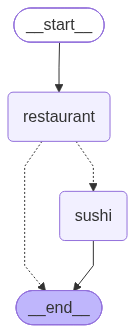

In [39]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [43]:
graph.invoke({"messages":["mes"]})

{'messages': ['mes'], 'question_length': 3}

In [41]:
graph.invoke({"messages":["SK온의 5주년을 축하해"]})

{'messages': ['SK온의 5주년을 축하해',
  'SK온의 5주년을 진심으로 축하드립니다! 지난 5년 동안의 성과와 혁신을 바탕으로 앞으로도 지속적인 발전과 성공을 이루시길 기원합니다. SK온의 모든 임직원분들에게 축하의 인사를 전하며, 다가오는 미래에도 많은 성취가 있기를 바랍니다.'],
 'question_length': 13}